In [1]:
import os
import glob
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
import timm

from tqdm import tqdm
from sklearn.metrics import roc_auc_score, accuracy_score, confusion_matrix

In [2]:
extract_path = "dataset"

for root, dirs, files in os.walk(extract_path):
    print(root, len(files))

dataset 1
dataset/dataset 1
dataset/dataset/train 1
dataset/dataset/train/vort 10000
dataset/dataset/train/no 10000
dataset/dataset/train/sphere 10000
dataset/dataset/val 1
dataset/dataset/val/vort 2500
dataset/dataset/val/no 2500
dataset/dataset/val/sphere 2500
dataset/__MACOSX 0
dataset/__MACOSX/dataset 1
dataset/__MACOSX/dataset/train 1
dataset/__MACOSX/dataset/val 1
dataset/train 1
dataset/train/vort 10000
dataset/train/no 10000
dataset/train/sphere 10000
dataset/val 1
dataset/val/vort 2500
dataset/val/no 2500
dataset/val/sphere 2500


Number of images: 10000
Shape: (1, 150, 150)
dtype: float64
Min: 0.0
Max: 1.0


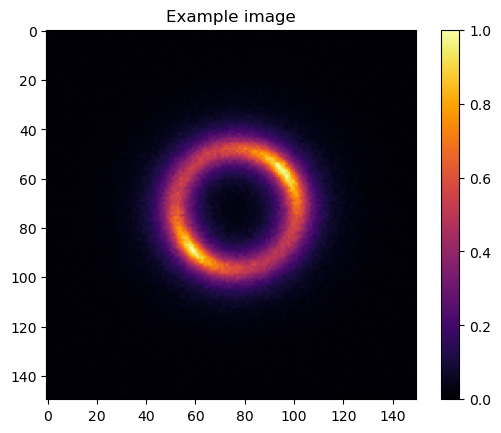

In [3]:
import numpy as np
import glob
import matplotlib.pyplot as plt

paths = glob.glob("dataset/train/no/*.npy")

print("Number of images:", len(paths))

img = np.load(paths[0])

print("Shape:", img.shape)
print("dtype:", img.dtype)
print("Min:", img.min())
print("Max:", img.max())

plt.imshow(img[0], cmap="inferno")
plt.colorbar()
plt.title("Example image")
plt.show()

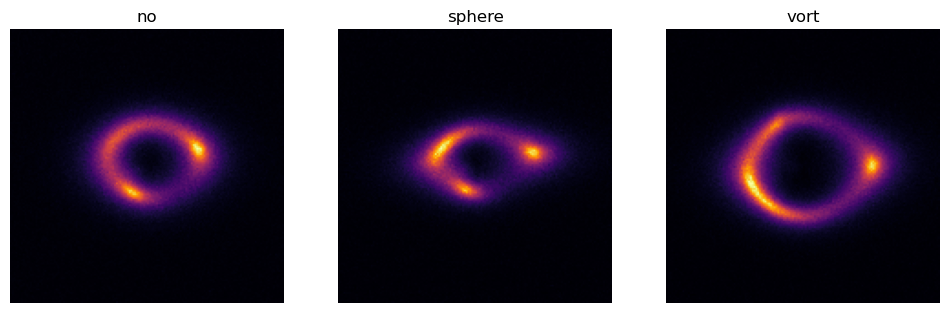

In [4]:
import random

classes = ["no", "sphere", "vort"]

plt.figure(figsize=(12,4))

for i, c in enumerate(classes):

    paths = glob.glob(f"dataset/train/{c}/*.npy")
    img = np.load(random.choice(paths))

    plt.subplot(1,3,i+1)
    plt.imshow(img[0], cmap="inferno")
    plt.title(c)
    plt.axis("off")

plt.show()

In [5]:
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print("Using device:", device)

Using device: mps


In [6]:
class ToTensor:

    def __call__(self, img):

        img = torch.tensor(img, dtype=torch.float32)

        # add channel only if missing
        if img.ndim == 2:
            img = img.unsqueeze(0)

        return img

class LogZScore:
    def __call__(self, img):

        img = torch.log1p(img)

        mean = img.mean()
        std = img.std() + 1e-8

        img = (img - mean) / std

        return img

In [7]:
train_transform = transforms.Compose([

    ToTensor(),

    transforms.Resize((224,224)),

    transforms.RandomRotation(360),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),

    LogZScore()
])

val_transform = transforms.Compose([
    ToTensor(),
    transforms.Resize((224,224)),
    LogZScore()
])

In [8]:
class LensDataset(Dataset):

    def __init__(self, root_dir, transform=None):

        self.paths = []
        self.labels = []
        self.transform = transform

        classes = ["no", "sphere", "vort"]

        for label, cls in enumerate(classes):

            files = glob.glob(os.path.join(root_dir, cls, "*.npy"))

            for f in files:
                self.paths.append(f)
                self.labels.append(label)

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):

        img = np.load(self.paths[idx])
        label = self.labels[idx]

        if self.transform:
            img = self.transform(img)

        return img.float(), label

In [9]:
train_dataset = LensDataset("dataset/train", transform=train_transform)
val_dataset = LensDataset("dataset/val", transform=val_transform)

print("Train size:", len(train_dataset))
print("Val size:", len(val_dataset))

Train size: 30000
Val size: 7500


In [10]:
train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=0
)

In [11]:
model_b1 = timm.create_model(
    "efficientnet_b1",
    pretrained=True,
    in_chans=1,
    num_classes=3
)

model_b1 = model_b1.to(device)

In [12]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.02)

optimizer_b1 = torch.optim.AdamW(model_b1.parameters(), lr=1e-4)

scheduler_b1 = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_b1, T_max=40)

In [13]:
EPOCHS = 40

for epoch in range(EPOCHS):

    print("Epoch:", epoch)

    for model, optimizer, scheduler in [
        # (model_b0, optimizer_b0, scheduler_b0),
         (model_b1, optimizer_b1, scheduler_b1)
    ]:

        model.train()

        train_loss = 0

        for images, labels in tqdm(train_loader):

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        scheduler.step()

    print("Train loss:", train_loss / len(train_loader))

Epoch: 0


  0%|          | 0/469 [00:00<?, ?it/s]

100%|██████████| 469/469 [08:00<00:00,  1.02s/it]


Train loss: 1.2849238584799045
Epoch: 1


100%|██████████| 469/469 [07:58<00:00,  1.02s/it]


...

Train loss: 0.12081954076981494
Epoch: 38


100%|██████████| 469/469 [08:03<00:00,  1.03s/it]


Train loss: 0.12163592879769644
Epoch: 39


100%|██████████| 469/469 [08:01<00:00,  1.03s/it]

Train loss: 0.1207037374123073


In [14]:
# Save trained model weights
torch.save(model_b1.state_dict(), "test_I_trained_wts_best_40ep.pth")

print("Model weights saved successfully!")

Model weights saved successfully!


In [15]:
def tta_predict(model, images):

    preds = []

    for k in range(4):

        rot = torch.rot90(images, k, dims=[2,3]).contiguous()
        preds.append(model(rot))

        flip = torch.flip(rot, dims=[3]).contiguous()
        preds.append(model(flip))

    preds = torch.stack(preds)
    preds = preds.mean(0)

    return preds

In [16]:
model_b1.eval()

all_probs = []
all_preds = []
all_labels = []

with torch.no_grad():

    for images, labels in tqdm(val_loader):

        images = images.to(device)

        #p0 = tta_predict(model_b0, images)
        p1 = tta_predict(model_b1, images)

        #p0 = F.softmax(p0, dim=1)
        p1 = F.softmax(p1, dim=1)

        #probs = 0.7 * p1 + 0.3 * p0   # weighted ensemble
        probs = p1
        preds = torch.argmax(probs, dim=1)

        all_probs.extend(probs.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

100%|██████████| 118/118 [02:44<00:00,  1.39s/it]


In [17]:
all_probs = np.array(all_probs)
all_labels = np.array(all_labels)

auc = roc_auc_score(all_labels, all_probs, multi_class="ovr")
print("Validation ROC-AUC:", auc)

acc = accuracy_score(all_labels, all_preds)
print("Validation Accuracy:", acc)

Validation ROC-AUC: 0.9978422533333333
Validation Accuracy: 0.9804


In [18]:
cm = confusion_matrix(all_labels, all_preds)

print("Confusion Matrix")
print(cm)

Confusion Matrix
[[2488   11    1]
 [  80 2390   30]
 [  10   15 2475]]


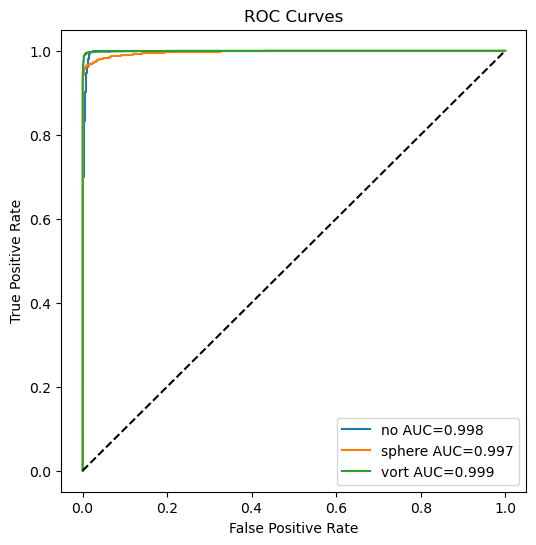

In [19]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt

# convert labels to one-hot
y_true = label_binarize(all_labels, classes=[0,1,2])

plt.figure(figsize=(6,6))

for i, name in enumerate(["no","sphere","vort"]):

    fpr, tpr, _ = roc_curve(y_true[:, i], all_probs[:, i])  # use probabilities
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{name} AUC={roc_auc:.3f}")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()

plt.show()

In [20]:
from sklearn.metrics import classification_report

class_names = ["no", "sphere", "vort"]

print(classification_report(
    all_labels,
    all_preds,
    target_names=class_names
))

              precision    recall  f1-score   support

          no       0.97      1.00      0.98      2500
      sphere       0.99      0.96      0.97      2500
        vort       0.99      0.99      0.99      2500

    accuracy                           0.98      7500
   macro avg       0.98      0.98      0.98      7500
weighted avg       0.98      0.98      0.98      7500



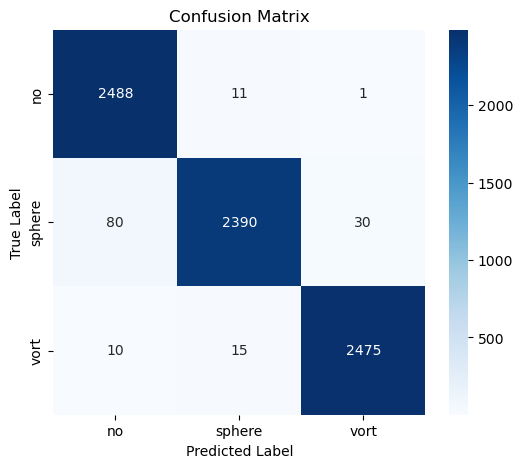

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(all_labels, all_preds)

class_names = ["no", "sphere", "vort"]

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

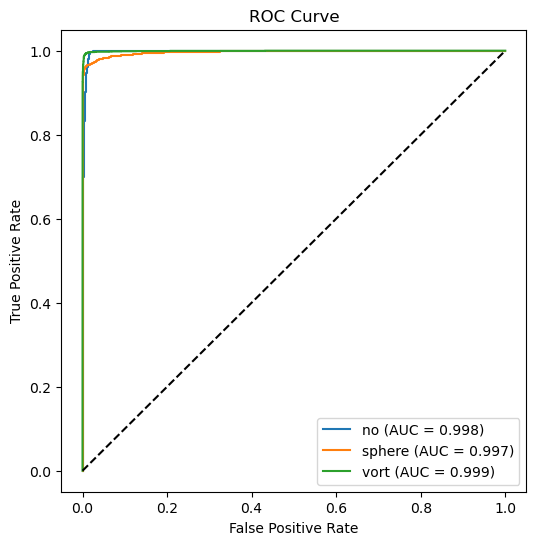

In [ ]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

y_true = label_binarize(all_labels, classes=[0,1,2])

plt.figure(figsize=(6,6))

for i, name in enumerate(["no","sphere","vort"]):

    fpr, tpr, _ = roc_curve(y_true[:,i], np.array(all_probs)[:,i])
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.3f})")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()